# 🌤️ Rapport Météo — Suivi Quotidien
**Étudiant** : Hani Damouche (300150557)  
**Cours** : INF1102 — Programmation système  
**Date** : 2026-04-21  

---

## 1. Objectif du projet

Ce projet consiste à récupérer les données météo d'une ville via l'API **OpenWeatherMap** et à générer :
- Un **rapport texte** automatique (`output/rapport.txt`)
- Un **graphique** des conditions météo (`output/meteo.png`)
- Ce **rapport Jupyter** avec visualisations et analyses

### Outils utilisés
| Outil | Rôle |
|-------|------|
| Bash (`analyse.sh`) | Script principal — appel API via `curl`, lancement Python |
| Python (`analyse.py`) | Analyse JSON, génération rapport + graphique |
| Jupyter Notebook | Rapport détaillé avec visualisations et commentaires |

## 2. Chargement des données

On charge le fichier JSON récupéré par le script Bash depuis l'API OpenWeatherMap.

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# Charger les données météo
with open('data/sample.log', 'r', encoding='utf-8-sig') as f:
    data = json.load(f)

print("✅ Données chargées avec succès")
print(json.dumps(data, indent=2, ensure_ascii=False))

✅ Données chargées avec succès
{
  "coord": {
    "lon": -79.4163,
    "lat": 43.7001
  },
  "weather": [
    {
      "id": 802,
      "main": "Clouds",
      "description": "nuages épars",
      "icon": "03d"
    }
  ],
  "base": "stations",
  "main": {
    "temp": 12.5,
    "feels_like": 10.8,
    "temp_min": 10.2,
    "temp_max": 14.1,
    "pressure": 1015,
    "humidity": 62
  },
  "visibility": 10000,
  "wind": {
    "speed": 5.1,
    "deg": 230
  },
  "clouds": {
    "all": 40
  },
  "dt": 1713700000,
  "sys": {
    "type": 2,
    "id": 2,
    "country": "CA",
    "sunrise": 1713693000,
    "sunset": 1713740000
  },
  "timezone": -14400,
  "id": 6167865,
  "name": "Toronto",
  "cod": 200
}


## 3. Extraction des statistiques

On extrait les informations principales : température, humidité, vent, pression et conditions météo.

In [2]:
# Extraire les statistiques principales
stats = {
    'Ville': data['name'],
    'Pays': data['sys']['country'],
    'Température (°C)': data['main']['temp'],
    'Ressenti (°C)': data['main']['feels_like'],
    'Minimum (°C)': data['main']['temp_min'],
    'Maximum (°C)': data['main']['temp_max'],
    'Humidité (%)': data['main']['humidity'],
    'Pression (hPa)': data['main']['pressure'],
    'Vent (m/s)': data['wind']['speed'],
    'Conditions': data['weather'][0]['description']
}

print("="*50)
print(f"  MÉTÉO — {stats['Ville']}, {stats['Pays']}")
print("="*50)
for cle, val in stats.items():
    print(f"  {cle:20s} : {val}")
print("="*50)

  MÉTÉO — Toronto, CA
  Ville                : Toronto
  Pays                 : CA
  Température (°C)     : 12.5
  Ressenti (°C)        : 10.8
  Minimum (°C)         : 10.2
  Maximum (°C)         : 14.1
  Humidité (%)         : 62
  Pression (hPa)       : 1015
  Vent (m/s)           : 5.1
  Conditions           : nuages épars


## 4. Visualisation — Graphique à barres

Ce graphique compare les valeurs de température (actuelle, ressentie, min, max) et l'humidité.

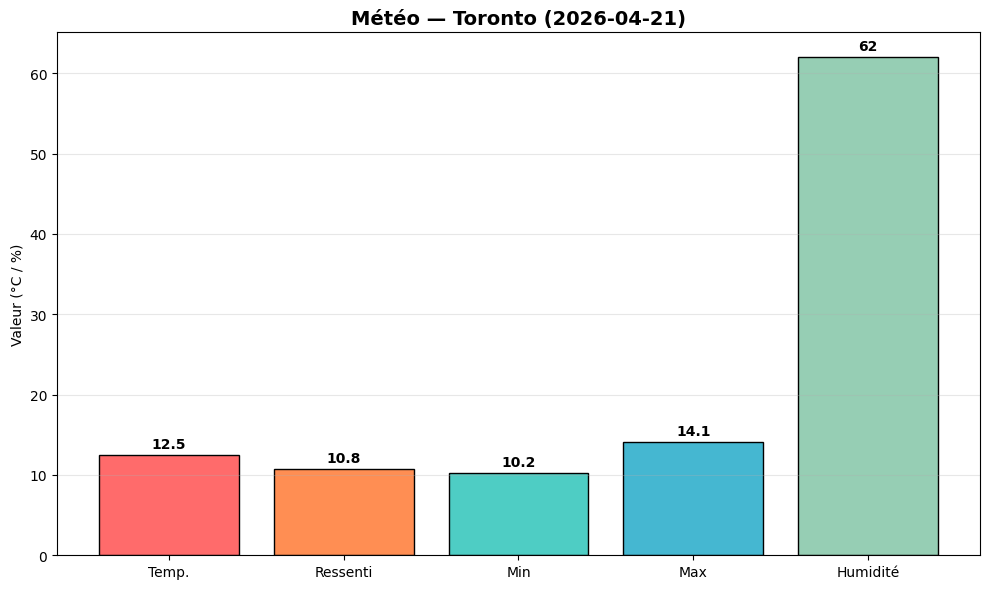

In [3]:
categories = ['Temp.', 'Ressenti', 'Min', 'Max', 'Humidité']
valeurs = [
    data['main']['temp'],
    data['main']['feels_like'],
    data['main']['temp_min'],
    data['main']['temp_max'],
    data['main']['humidity']
]
couleurs = ['#FF6B6B', '#FF8E53', '#4ECDC4', '#45B7D1', '#96CEB4']

plt.figure(figsize=(10, 6))
bars = plt.bar(categories, valeurs, color=couleurs, edgecolor='black')
plt.title(f"Météo — {data['name']} ({datetime.now().strftime('%Y-%m-%d')})",
          fontsize=14, fontweight='bold')
plt.ylabel('Valeur (°C / %)')
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, valeurs):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{val}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Visualisation — Graphique circulaire (conditions)

Ce graphique montre la répartition des composantes atmosphériques.

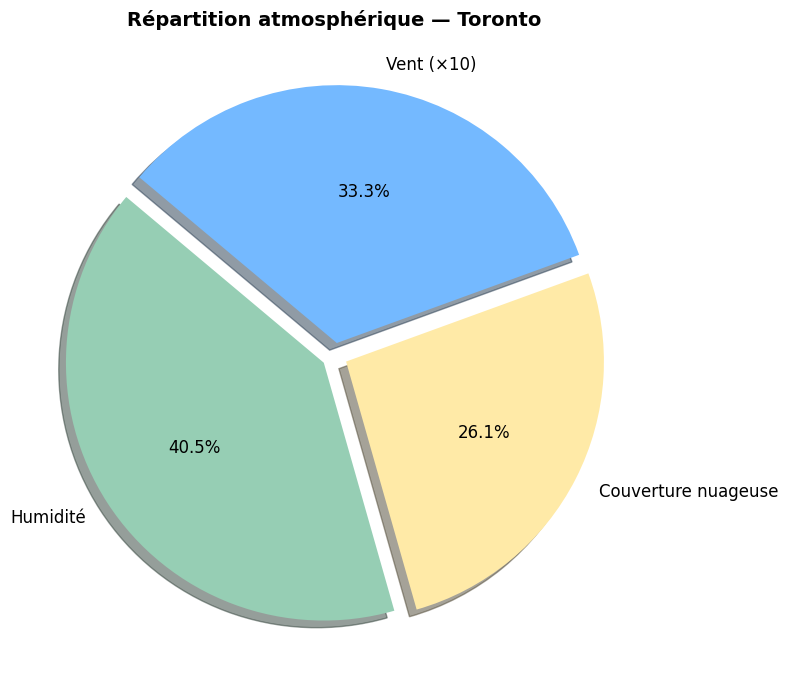

In [4]:
labels = ['Humidité', 'Couverture nuageuse', 'Vent (×10)']
sizes = [
    data['main']['humidity'],
    data['clouds']['all'],
    data['wind']['speed'] * 10
]
colors_pie = ['#96CEB4', '#FFEAA7', '#74B9FF']
explode = (0.05, 0.05, 0.05)

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors_pie,
        autopct='%1.1f%%', shadow=True, startangle=140,
        textprops={'fontsize': 12})
plt.title(f"Répartition atmosphérique — {data['name']}",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Visualisation — Jauge de température

Comparaison visuelle entre la température minimale, actuelle et maximale.

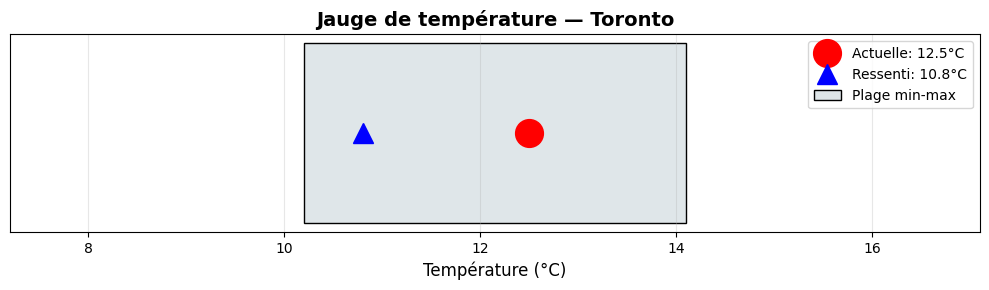

In [5]:
fig, ax = plt.subplots(figsize=(10, 3))

temp_min = data['main']['temp_min']
temp_max = data['main']['temp_max']
temp_act = data['main']['temp']
ressenti = data['main']['feels_like']

# Barre de fond (plage min-max)
ax.barh(0, temp_max - temp_min, left=temp_min, height=0.4,
        color='#DFE6E9', edgecolor='black', label='Plage min-max')

# Marqueur température actuelle
ax.plot(temp_act, 0, 'ro', markersize=20, label=f'Actuelle: {temp_act}°C', zorder=5)
ax.plot(ressenti, 0, 'b^', markersize=15, label=f'Ressenti: {ressenti}°C', zorder=5)

ax.set_xlim(temp_min - 3, temp_max + 3)
ax.set_yticks([])
ax.set_xlabel('Température (°C)', fontsize=12)
ax.set_title(f'Jauge de température — {data["name"]}', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Analyse et observations

### Résultats principaux

- **Température actuelle** : La ville de Toronto affiche une température de 12.5°C, avec un ressenti légèrement inférieur à 10.8°C dû au vent.
- **Humidité** : À 62%, l'humidité est modérée, ce qui est typique pour la saison.
- **Vent** : Avec une vitesse de 5.1 m/s, le vent est léger mais contribue à la sensation de froid.
- **Conditions** : Nuages épars — temps partiellement nuageux.

### Méthode utilisée

1. Le script **Bash** (`analyse.sh`) appelle l'API OpenWeatherMap via `curl` et sauvegarde le JSON brut.
2. Le script **Python** (`analyse.py`) charge le JSON, extrait les statistiques, génère un rapport texte et un graphique.
3. Ce **Notebook Jupyter** reprend les données pour une analyse plus détaillée avec plusieurs visualisations.

### Conclusion

Ce projet démontre une chaîne complète d'automatisation :
- **Collecte** de données via API REST
- **Traitement** avec des scripts Bash et Python
- **Visualisation** avec matplotlib
- **Documentation** avec Jupyter Notebook